# Notebook 2 — DCA Fitting & Feature Extraction
**Project:** Predicting Oil Well Output Using Hybrid DCA-LSTM  
**Well:** NO 15/9-F-14 H (Volve Oilfield, Norway)  
**Methodology ref:** §3.2.3 (Adefisan Peace Folashade, U22CS1009)

### Pre-requisite
Run **01_Preprocessing.ipynb** first — this notebook reads from `pipeline_outputs/`.

### Steps in this notebook
1. Load cleaned training data from Notebook 1
2. Define Arps DCA model functions (exponential, hyperbolic, harmonic)
3. Fit hyperbolic DCA to training data using non-linear least-squares (Levenberg-Marquardt)
4. Assess goodness-of-fit on training set
5. Generate DCA trend over the full time horizon (train + val + test)
6. Sensitivity comparison: exponential vs hyperbolic vs harmonic
7. Compute DCA residuals — these become the LSTM targets
8. Save DCA results and residuals for Notebook 3

---

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

OUTPUT_DIR = 'pipeline_outputs'
print('Imports loaded ✓')

Imports loaded ✓


## Step 1 — Load Clean Data from Notebook 1

In [2]:
df_train = pd.read_csv(f'{OUTPUT_DIR}/f14h_train.csv', parse_dates=['Date'])
df_val   = pd.read_csv(f'{OUTPUT_DIR}/f14h_val.csv',   parse_dates=['Date'])
df_test  = pd.read_csv(f'{OUTPUT_DIR}/f14h_test.csv',  parse_dates=['Date'])
df_clean = pd.read_csv(f'{OUTPUT_DIR}/f14h_clean.csv', parse_dates=['Date'])

with open(f'{OUTPUT_DIR}/split_info.pkl', 'rb') as f:
    split_info = pickle.load(f)

n_train = split_info['n_train']
n_val   = split_info['n_val']
n_test  = split_info['n_test']
n_total = split_info['n_total']

print(f'Train: {len(df_train)} months  |  Val: {len(df_val)} months  |  Test: {len(df_test)} months')

# Full date index and actual production array
all_dates  = df_clean['Date'].values
actual_all = df_clean['OIL_PROD'].values
train_prod = df_train['OIL_PROD'].values
t_train    = np.arange(len(train_prod), dtype=float)

Train: 67 months  |  Val: 14 months  |  Test: 16 months


## Step 2 — Arps DCA Model Definitions (§3.2.3)

In [3]:
# ── Arps (1945) decline curve model functions ─────────────────────────────────

def arps_hyperbolic(t, q0, Di, b):
    """
    Hyperbolic decline: q(t) = q0 / (1 + b*Di*t)^(1/b)
    Generalises exponential (b→0) and harmonic (b=1).
    Parameters
    ----------
    t  : time index (0 = first production month)
    q0 : initial production rate (Sm³/month)
    Di : initial nominal decline rate (per month)
    b  : hyperbolic exponent [0, 1]
    """
    return q0 / np.power(1.0 + b * Di * t, 1.0 / b)

def arps_exponential(t, q0, Di):
    """Exponential decline: q(t) = q0 * exp(-Di*t)"""
    return q0 * np.exp(-Di * t)

def arps_harmonic(t, q0, Di):
    """Harmonic decline: q(t) = q0 / (1 + Di*t)"""
    return q0 / (1.0 + Di * t)

print('Arps DCA functions defined ✓')

Arps DCA functions defined ✓


## Step 3 — Fit Hyperbolic DCA to Training Data (Levenberg-Marquardt, §3.2.3)

In [4]:
q_max = float(train_prod.max())

# Initial guesses and physical bounds
p0     = [q_max, 0.05, 0.5]          # [q0, Di, b]
bounds = ([0, 1e-6, 0.0],             # lower bounds
          [q_max * 2, 5.0, 1.0])      # upper bounds (b ≤ 1 per Arps convention)

popt, pcov = curve_fit(
    arps_hyperbolic,
    t_train,
    train_prod,
    p0=p0,
    bounds=bounds,
    method='trf',        # Trust Region Reflective — handles bounds; equivalent to L-M with bounds
    maxfev=20000
)

q0_fit, Di_fit, b_fit = popt
perr = np.sqrt(np.diag(pcov))   # 1-σ parameter uncertainties

print('Hyperbolic DCA Fitted Parameters')
print(f'  q₀  = {q0_fit:>12,.2f} Sm³/month   (±{perr[0]:,.2f})')
print(f'  Dᵢ  = {Di_fit:>12.6f} month⁻¹     (±{perr[1]:.6f})')
print(f'  b   = {b_fit:>12.4f}              (±{perr[2]:.4f})')

Hyperbolic DCA Fitted Parameters
  q₀  =   117,068.07 Sm³/month   (±4,743.42)
  Dᵢ  =     0.025419 month⁻¹     (±0.001662)
  b   =       0.0000              (±0.0032)


## Step 4 — Goodness-of-Fit on Training Set

In [5]:
q_hat_train = arps_hyperbolic(t_train, q0_fit, Di_fit, b_fit)

rmse_fit = np.sqrt(mean_squared_error(train_prod, q_hat_train))
mae_fit  = mean_absolute_error(train_prod, q_hat_train)
r2_fit   = r2_score(train_prod, q_hat_train)

print('DCA Training Fit Quality')
print(f'  RMSE : {rmse_fit:>12,.2f} Sm³/month')
print(f'  MAE  : {mae_fit:>12,.2f} Sm³/month')
print(f'  R²   : {r2_fit:>12.4f}')

DCA Training Fit Quality
  RMSE :    14,820.07 Sm³/month
  MAE  :     9,549.85 Sm³/month
  R²   :       0.7851


## Step 5 — Generate Full-Horizon DCA Trend (Train + Val + Test)

In [6]:
# t=0 anchored at the first training month; extend continuously over the full period
t_full     = np.arange(n_total, dtype=float)
trend_full = arps_hyperbolic(t_full, q0_fit, Di_fit, b_fit)
trend_full = np.clip(trend_full, 0, None)   # no negative forecasts

# Segment the trend for each period
trend_train = trend_full[:n_train]
trend_val   = trend_full[n_train : n_train + n_val]
trend_test  = trend_full[n_train + n_val :]

print(f'DCA trend generated over {n_total} months ✓')
print(f'  Final forecast value (end of test) : {trend_test[-1]:,.2f} Sm³/month')

DCA trend generated over 97 months ✓
  Final forecast value (end of test) : 10,201.61 Sm³/month


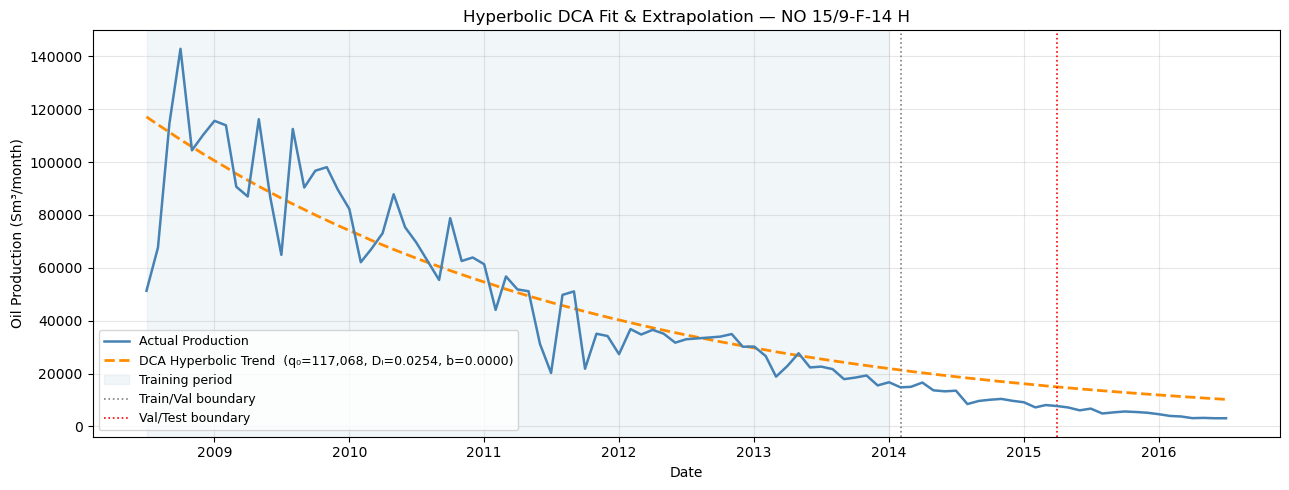

Saved: fig_05_dca_fit.png


In [7]:
# Plot DCA fit and extrapolation
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(all_dates, actual_all, color='steelblue', lw=1.8, label='Actual Production', zorder=3)
ax.plot(all_dates, trend_full, color='darkorange', lw=2.0, linestyle='--',
        label=f'DCA Hyperbolic Trend  (q₀={q0_fit:,.0f}, Dᵢ={Di_fit:.4f}, b={b_fit:.4f})')

# Shade training region
ax.axvspan(all_dates[0], all_dates[n_train-1],
           alpha=0.07, color='steelblue', label='Training period')
ax.axvline(x=all_dates[n_train], color='gray',
           linestyle=':', lw=1.2, label='Train/Val boundary')
ax.axvline(x=all_dates[n_train + n_val], color='red',
           linestyle=':', lw=1.2, label='Val/Test boundary')

ax.set_title('Hyperbolic DCA Fit & Extrapolation — NO 15/9-F-14 H', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Oil Production (Sm³/month)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_05_dca_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_05_dca_fit.png')

## Step 6 — Sensitivity: DCA Model Type Comparison

In [8]:
# Fit exponential and harmonic for comparison
sens_results = {}

# Hyperbolic (already fitted above)
test_actual = df_test['OIL_PROD'].values

for model_name, func, p0_, bounds_ in [
    ('Hyperbolic', arps_hyperbolic,
     [q_max, 0.05, 0.5],
     ([0, 1e-6, 0.0], [q_max*2, 5.0, 1.0])),
    ('Exponential', arps_exponential,
     [q_max, 0.05],
     ([0, 1e-6], [q_max*2, 5.0])),
    ('Harmonic', arps_harmonic,
     [q_max, 0.05],
     ([0, 1e-6], [q_max*2, 5.0])),
]:
    try:
        popt_s, _ = curve_fit(func, t_train, train_prod,
                               p0=p0_, bounds=bounds_, maxfev=20000)
        t_test_s  = np.arange(n_train, n_train + n_test, dtype=float)
        pred_test = np.clip(func(t_test_s, *popt_s), 0, None)
        r2_s  = r2_score(test_actual, pred_test)
        rmse_s = np.sqrt(mean_squared_error(test_actual, pred_test))
        sens_results[model_name] = {
            'params': popt_s, 'RMSE_test': rmse_s, 'R2_test': r2_s,
            'pred_test': pred_test
        }
        print(f'  {model_name:<15}  RMSE_test={rmse_s:>10,.1f}  R²_test={r2_s:.4f}')
    except Exception as e:
        print(f'  {model_name:<15}  FAILED: {e}')

print()
print('→ Hyperbolic selected as primary DCA model for hybrid framework (best R², §3.2.3)')

  Hyperbolic       RMSE_test=  12,841.5  R²_test=-77.6068
  Exponential      RMSE_test=  12,839.9  R²_test=-77.5867
  Harmonic         RMSE_test=  24,287.4  R²_test=-280.1829

→ Hyperbolic selected as primary DCA model for hybrid framework (best R², §3.2.3)


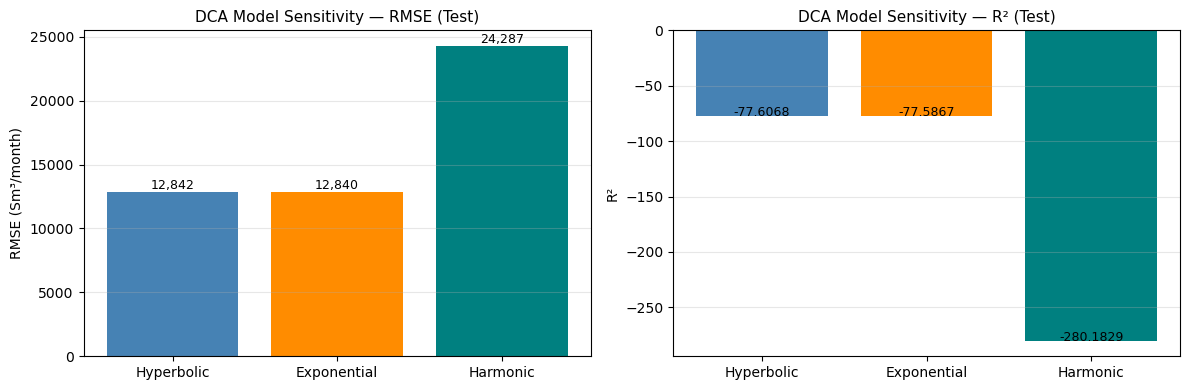

Saved: fig_06_dca_sensitivity.png


In [9]:
# DCA model type sensitivity bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = list(sens_results.keys())
rmses  = [sens_results[m]['RMSE_test'] for m in models]
r2s    = [sens_results[m]['R2_test']   for m in models]
colors = ['steelblue', 'darkorange', 'teal']

axes[0].bar(models, rmses, color=colors)
axes[0].set_title('DCA Model Sensitivity — RMSE (Test)', fontsize=11)
axes[0].set_ylabel('RMSE (Sm³/month)')
for i, v in enumerate(rmses):
    axes[0].text(i, v + max(rmses)*0.01, f'{v:,.0f}', ha='center', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models, r2s, color=colors)
axes[1].set_title('DCA Model Sensitivity — R² (Test)', fontsize=11)
axes[1].set_ylabel('R²')
for i, v in enumerate(r2s):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_06_dca_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_06_dca_sensitivity.png')

## Step 7 — Compute DCA Residuals (Actual − DCA Trend)
> These are the **LSTM learning targets**: the non-linear, non-systematic dynamics the deterministic DCA model cannot capture.

In [10]:
residuals_all   = actual_all - trend_full
residuals_train = residuals_all[:n_train]
residuals_val   = residuals_all[n_train : n_train + n_val]
residuals_test  = residuals_all[n_train + n_val :]

print('Residual Statistics (training period):')
print(f'  Mean  : {residuals_train.mean():>12,.2f} Sm³/month')
print(f'  Std   : {residuals_train.std():>12,.2f} Sm³/month')
print(f'  Min   : {residuals_train.min():>12,.2f} Sm³/month')
print(f'  Max   : {residuals_train.max():>12,.2f} Sm³/month')

Residual Statistics (training period):
  Mean  :      -481.65 Sm³/month
  Std   :    14,812.24 Sm³/month
  Min   :   -65,782.99 Sm³/month
  Max   :    34,344.29 Sm³/month


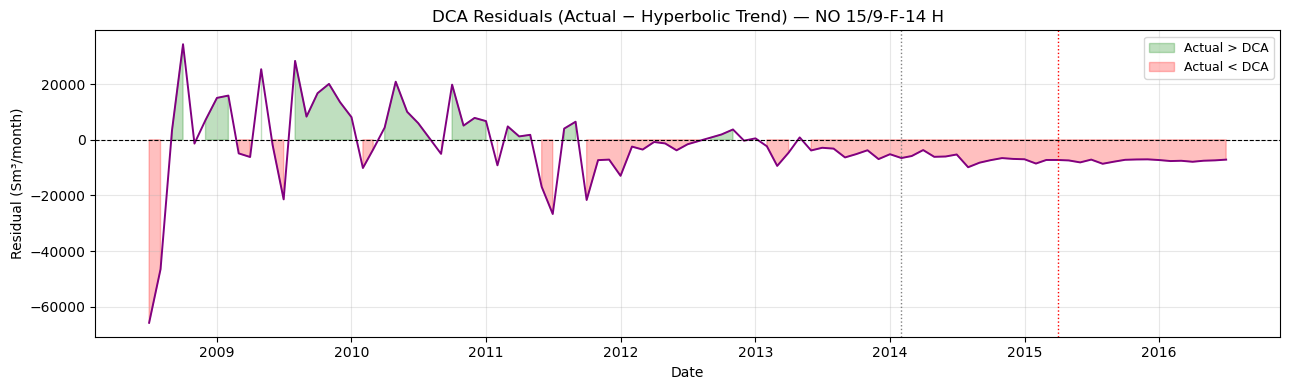

Saved: fig_07_residuals.png


In [11]:
# Residual plot
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(all_dates, residuals_all, color='purple', lw=1.4)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.fill_between(all_dates, residuals_all, 0,
                where=(residuals_all >= 0), alpha=0.25, color='green', label='Actual > DCA')
ax.fill_between(all_dates, residuals_all, 0,
                where=(residuals_all < 0),  alpha=0.25, color='red',   label='Actual < DCA')
ax.axvline(x=all_dates[n_train], color='gray', linestyle=':', lw=1)
ax.axvline(x=all_dates[n_train + n_val], color='red', linestyle=':', lw=1)

ax.set_title('DCA Residuals (Actual − Hyperbolic Trend) — NO 15/9-F-14 H', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Residual (Sm³/month)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_07_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_07_residuals.png')

## Step 8 — Save DCA Results for Notebook 3

In [12]:
dca_artefacts = {
    # Fitted parameters
    'q0'   : q0_fit,
    'Di'   : Di_fit,
    'b'    : b_fit,
    # Goodness of fit
    'RMSE_train_fit' : rmse_fit,
    'MAE_train_fit'  : mae_fit,
    'R2_train_fit'   : r2_fit,
    # Trend arrays
    'trend_full'  : trend_full,
    'trend_train' : trend_train,
    'trend_val'   : trend_val,
    'trend_test'  : trend_test,
    # Residual arrays
    'residuals_all'   : residuals_all,
    'residuals_train' : residuals_train,
    'residuals_val'   : residuals_val,
    'residuals_test'  : residuals_test,
    # Sensitivity results
    'sensitivity' : {k: {'RMSE_test': v['RMSE_test'], 'R2_test': v['R2_test']}
                     for k, v in sens_results.items()},
}

with open(f'{OUTPUT_DIR}/dca_artefacts.pkl', 'wb') as f:
    pickle.dump(dca_artefacts, f)

print('Artefacts saved to pipeline_outputs/dca_artefacts.pkl')
print()
print('Notebook 2 complete ✓  →  proceed to 03_LSTM_Training.ipynb')

Artefacts saved to pipeline_outputs/dca_artefacts.pkl

Notebook 2 complete ✓  →  proceed to 03_LSTM_Training.ipynb
